# Credit Card Fraud Detection

This notebook builds a classification model to detect fraudulent credit card transactions in a highly imbalanced dataset.

## 1. Problem Definition

In a statement,
> Given anonymized transaction data, can we identify which transactions are fraudulent?

## 2. Data

The dataset is the [Credit Card Fraud Detection dataset](https://www.kaggle.com/mlg-ulb/creditcardfraud) from the Machine Learning Group at ULB (Universite Libre de Bruxelles), available on Kaggle.

It contains 284,807 transactions made by European cardholders over two days in September 2013. Only 492 of them are fraudulent, about 0.17% of the total. Because of confidentiality, the original transaction features were transformed with PCA into 28 anonymized components (`V1` to `V28`); only `Time`, `Amount`, and `Class` (the target) keep their original meaning.

## 3. Evaluation

Because the dataset is heavily imbalanced, accuracy alone would be misleading here: a model predicting "not fraud" for every transaction would already score above 99.8% accuracy while catching zero fraud. The evaluation will focus on precision, recall, and F1-score for the fraud class, plus ROC-AUC and precision-recall AUC, which are more informative on imbalanced data.

## 4. Features

Data dictionary (from the dataset description on Kaggle):

* `Time` - seconds elapsed between this transaction and the first transaction in the dataset
* `V1` to `V28` - principal components from a PCA transformation, anonymized for confidentiality reasons (the original features and any background information about them are not available)
* `Amount` - transaction amount
* `Class` - target variable: 1 = fraud, 0 = normal transaction

## 5. Preparing the tools

We use pandas, NumPy, matplotlib and seaborn for data analysis and visualization, and scikit-learn for modelling.

In [1]:
# Import all tools we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Data Exploration (EDA)

The goal here is to understand the data before doing any modelling:
1. How many transactions and features do we have?
2. Are there missing values?
3. How imbalanced is the target class, exactly?
4. What do `Time` and `Amount` look like for fraud vs normal transactions?

In [2]:
# Load the dataset
df = pd.read_csv("../data/creditcard.csv")
df.shape

(284807, 31)

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
# Check for missing values
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Class balance

In [7]:
# How many fraud vs normal transactions do we have?
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


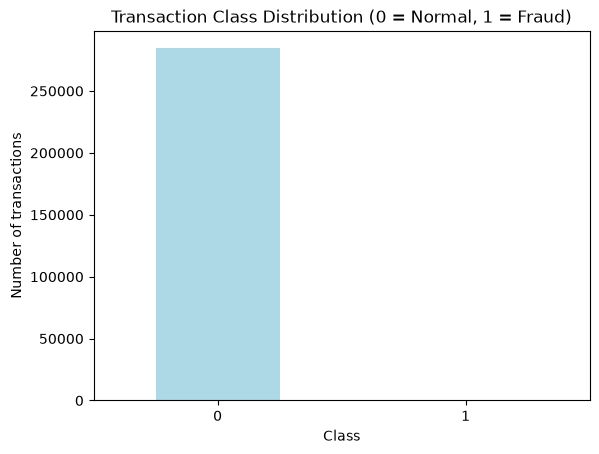

In [8]:
class_counts.plot(kind="bar", color=["lightblue", "salmon"])
plt.title("Transaction Class Distribution (0 = Normal, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Number of transactions")
plt.xticks(rotation=0)
plt.show()

### Amount and Time by class

`V1`-`V28` are already PCA components, roughly centered and scaled. `Amount` and `Time` are still in their original units, so they are worth checking separately.

/var/folders/nr/65x3h_k54bx5627zbxwfphyc0000gn/T/ipykernel_53736/3965736146.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Normal", "Fraud"])
/var/folders/nr/65x3h_k54bx5627zbxwfphyc0000gn/T/ipykernel_53736/3965736146.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Normal", "Fraud"])


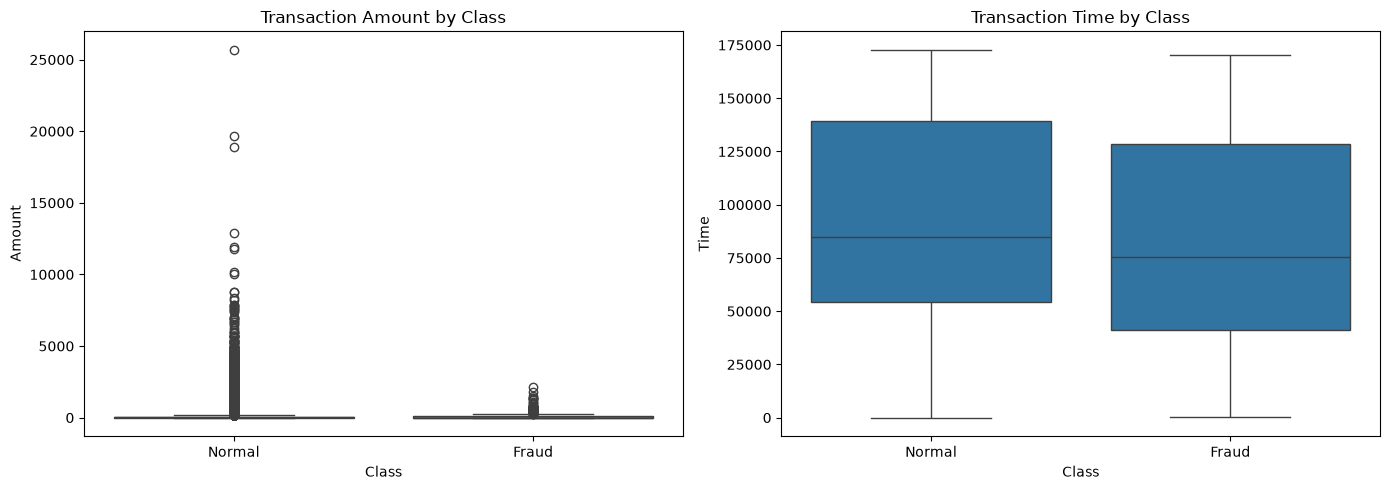

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0])
axes[0].set_title("Transaction Amount by Class")
axes[0].set_xticklabels(["Normal", "Fraud"])

sns.boxplot(data=df, x="Class", y="Time", ax=axes[1])
axes[1].set_title("Transaction Time by Class")
axes[1].set_xticklabels(["Normal", "Fraud"])

plt.tight_layout()
plt.show()

### Correlation with the target

In [10]:
# Correlation of each feature with the target, sorted by absolute value
corr_with_target = df.corr()["Class"].drop("Class").sort_values(key=abs, ascending=False)
corr_with_target.head(15)

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
V1    -0.101347
V9    -0.097733
V5    -0.094974
V2     0.091289
V6    -0.043643
Name: Class, dtype: float64

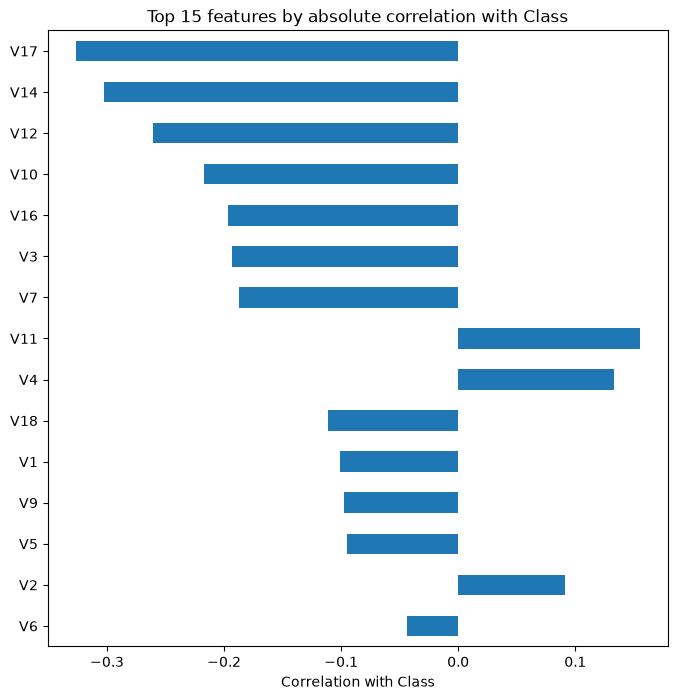

In [11]:
plt.figure(figsize=(8, 8))
corr_with_target.head(15).plot(kind="barh")
plt.title("Top 15 features by absolute correlation with Class")
plt.xlabel("Correlation with Class")
plt.gca().invert_yaxis()
plt.show()

## Preprocessing

`V1` to `V28` are already PCA-transformed and do not need scaling. `Amount` and `Time` are on very different scales (dollars vs seconds), so we scale them before modelling.

We split into train/test first, then fit the scaler on the training set only, and apply it to both sets. This avoids leaking information about the test set's distribution into the scaler.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

X = df.drop("Class", axis=1)
y = df["Class"]

# Stratify on y to keep the same fraud ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape, y_train.sum(), y_test.sum()

((227845, 30), (56962, 30), np.int64(394), np.int64(98))

In [13]:
scaler = RobustScaler()

# Fit on training data only, then apply the same transformation to both sets
X_train[["Amount", "Time"]] = scaler.fit_transform(X_train[["Amount", "Time"]])
X_test[["Amount", "Time"]] = scaler.transform(X_test[["Amount", "Time"]])

X_train[["Amount", "Time"]].describe()

,Amount,Time
count,227845.000000,227845.000000
mean,0.921034,0.118400
std,3.489528,0.557795
min,-0.306193,-0.996112
25%,-0.227697,-0.359155
50%,0.000000,0.000000
75%,0.772303,0.640845
max,357.260404,1.033488


## Evaluation function

Since the dataset is heavily imbalanced, accuracy is not a useful metric on its own. We build a function that reports precision, recall, f1-score, ROC-AUC, and PR-AUC (average precision) for the fraud class, plus a confusion matrix.

In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

def evaluate_model(model, X_test, y_test, model_name="Model", plot=True):
    """
    Evaluate a fitted classifier on the fraud detection task.
    Returns a dict of metrics and optionally plots ROC and Precision-Recall curves.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"--- {model_name} ---")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Fraud"]))

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC (average precision): {pr_auc:.4f}")

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cbar=False, ax=axes[0],
                    xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
        axes[0].set_title(f"{model_name} - Confusion Matrix")
        axes[0].set_xlabel("Predicted")
        axes[0].set_ylabel("True")

        RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
        axes[1].set_title(f"{model_name} - ROC Curve")

        PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2])
        axes[2].set_title(f"{model_name} - Precision-Recall Curve")

        plt.tight_layout()
        plt.show()

    return {
        "model": model_name,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }

results = []

## Baseline model (no imbalance handling)

A plain LogisticRegression on the raw class distribution, as a reference point before trying anything to handle the imbalance.

--- Baseline LogisticRegression ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9572
PR-AUC (average precision): 0.7388


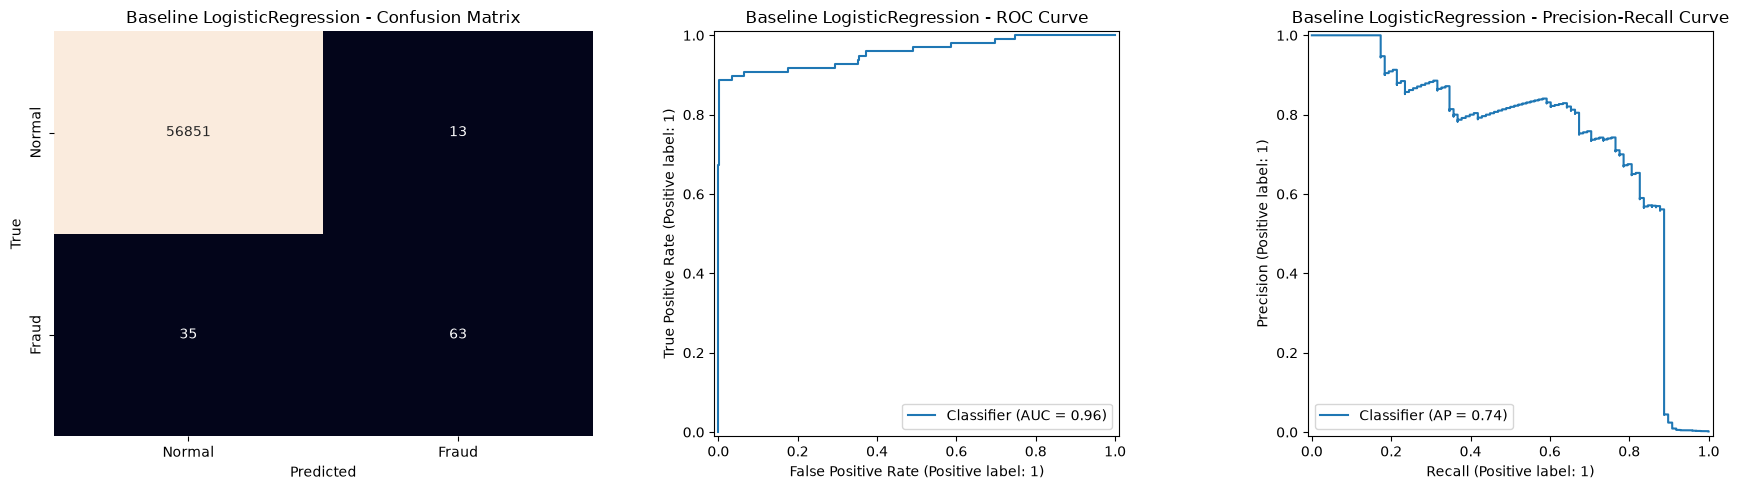

In [15]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

results.append(evaluate_model(baseline_model, X_test, y_test, model_name="Baseline LogisticRegression"))

## Handling class imbalance

Two common approaches, tried separately:
1. **Class weights**: tell the model to penalize mistakes on the minority class (fraud) more heavily, without changing the training data itself.
2. **SMOTE (Synthetic Minority Oversampling Technique)**: generate synthetic fraud examples in the training set only, to rebalance the classes before fitting.

SMOTE is applied strictly on the training set, after the train/test split. Applying it before the split (or on the test set) would leak synthetic near-duplicates of test fraud cases into training, which would inflate the evaluation metrics artificially - the same kind of mistake as fitting preprocessing statistics on data that includes the validation/test set.

`imbalanced-learn` needs to be installed for the SMOTE step: `pip install imbalanced-learn`.

### Class weights

--- LogisticRegression (class_weight=balanced) ---
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9720
PR-AUC (average precision): 0.7175


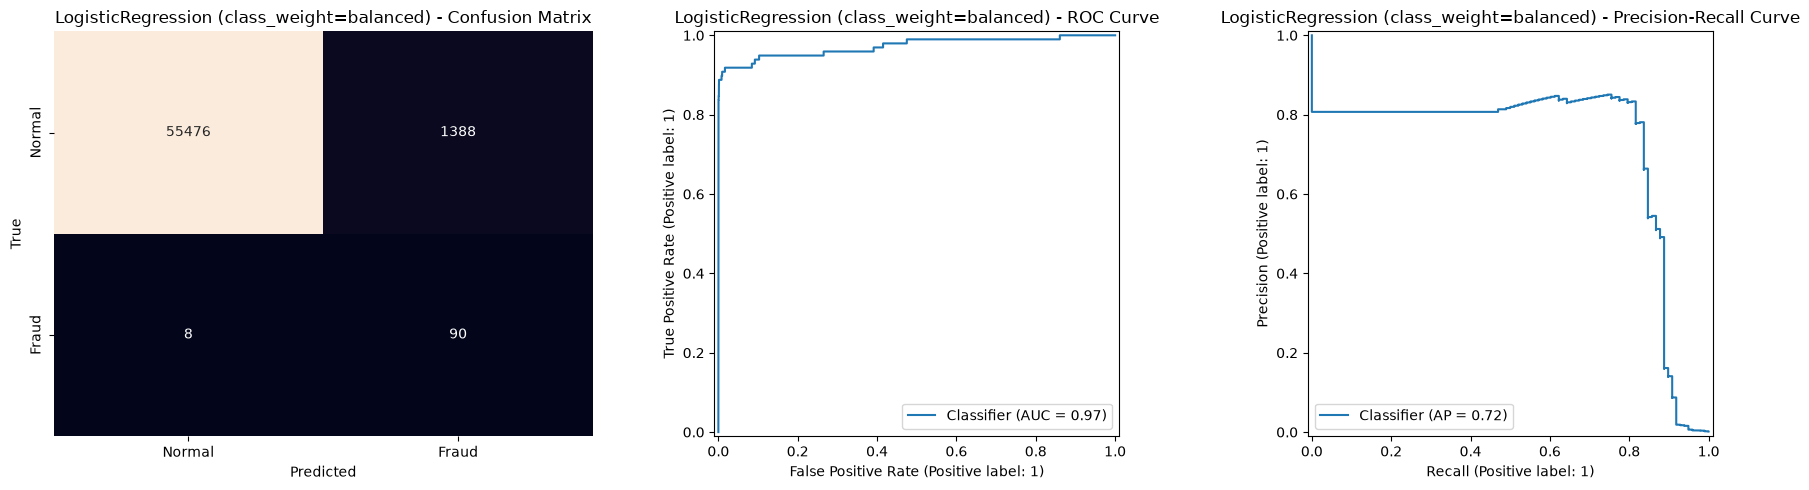

In [16]:
from sklearn.ensemble import RandomForestClassifier

log_reg_balanced = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg_balanced.fit(X_train, y_train)
results.append(evaluate_model(log_reg_balanced, X_test, y_test, model_name="LogisticRegression (class_weight=balanced)"))

--- RandomForest (class_weight=balanced) ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.92      0.79      0.85        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9573
PR-AUC (average precision): 0.8626


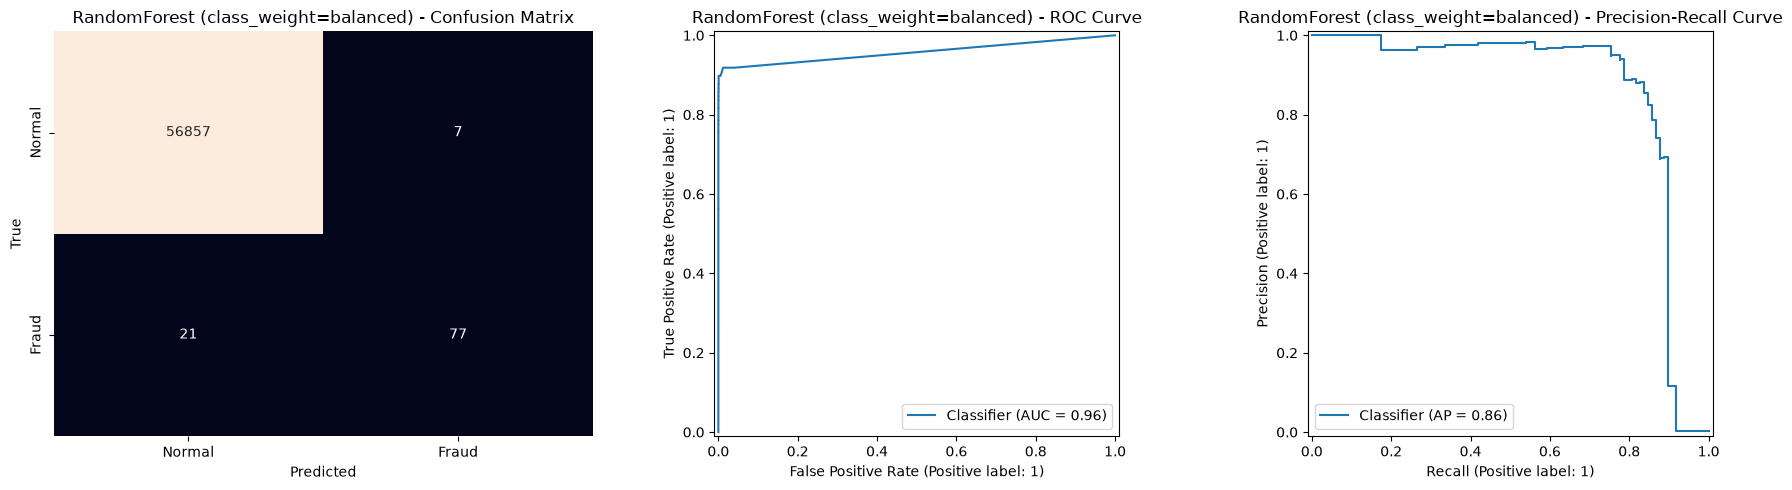

In [17]:
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42)
rf_balanced.fit(X_train, y_train)
results.append(evaluate_model(rf_balanced, X_test, y_test, model_name="RandomForest (class_weight=balanced)"))

### SMOTE oversampling

In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Confirm the classes are now balanced in the training set (test set is untouched)
y_train_smote.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

--- LogisticRegression (SMOTE) ---
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9712
PR-AUC (average precision): 0.7251


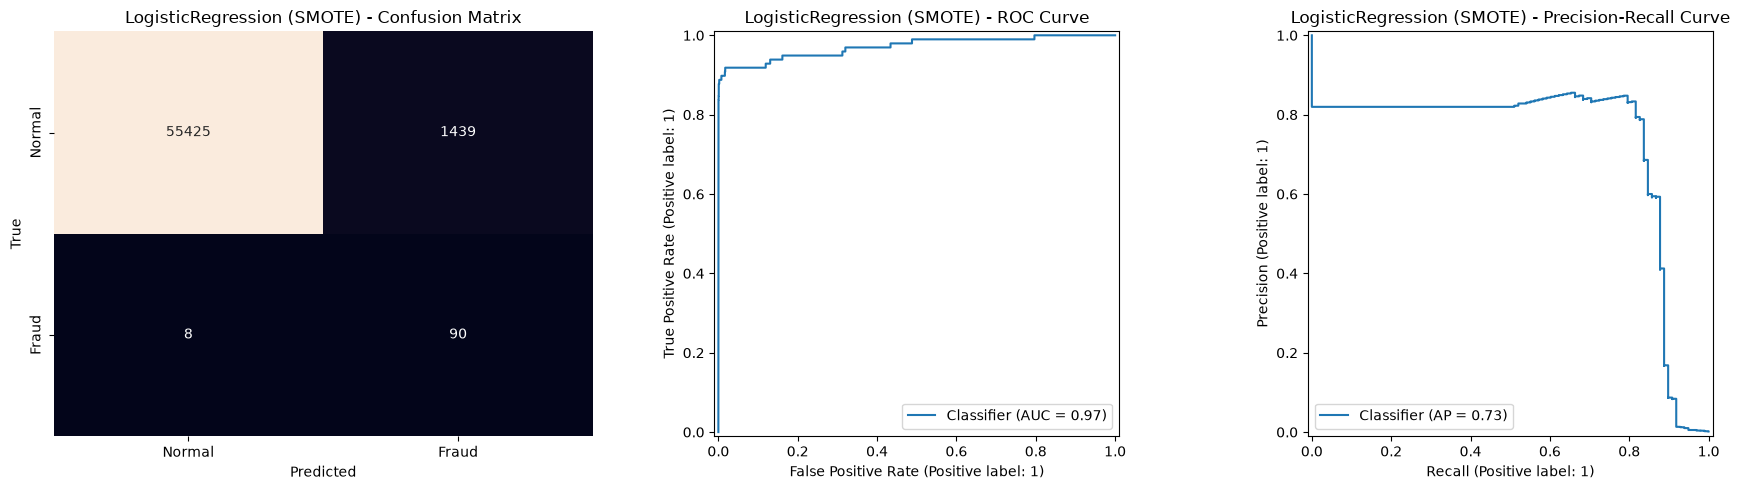

In [19]:
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_train_smote, y_train_smote)
results.append(evaluate_model(log_reg_smote, X_test, y_test, model_name="LogisticRegression (SMOTE)"))

--- RandomForest (SMOTE) ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.86      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9733
PR-AUC (average precision): 0.8703


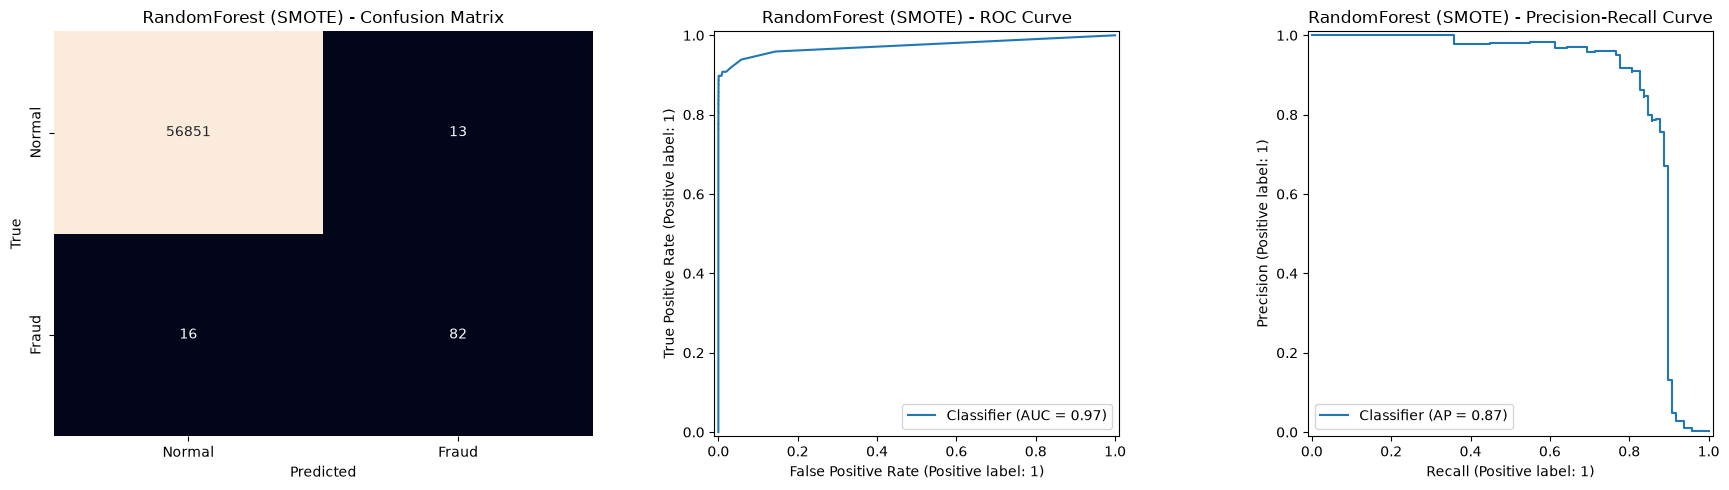

In [20]:
rf_smote = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
results.append(evaluate_model(rf_smote, X_test, y_test, model_name="RandomForest (SMOTE)"))

## Model comparison

All five models (baseline, two class-weighted, two SMOTE-based) are evaluated on the exact same, untouched test set, so their metrics are directly comparable.

In [21]:
results_df = pd.DataFrame(results).set_index("model")
results_df.sort_values("pr_auc", ascending=False)

,precision,recall,f1,roc_auc,pr_auc
model,,,,,
RandomForest (SMOTE),0.863158,0.836735,0.849741,0.973283,0.870296
RandomForest (class_weight=balanced),0.916667,0.785714,0.846154,0.957313,0.862596
Baseline LogisticRegression,0.828947,0.642857,0.724138,0.957233,0.738833
LogisticRegression (SMOTE),0.058862,0.918367,0.110633,0.971206,0.725058
LogisticRegression (class_weight=balanced),0.060893,0.918367,0.114213,0.972045,0.717454


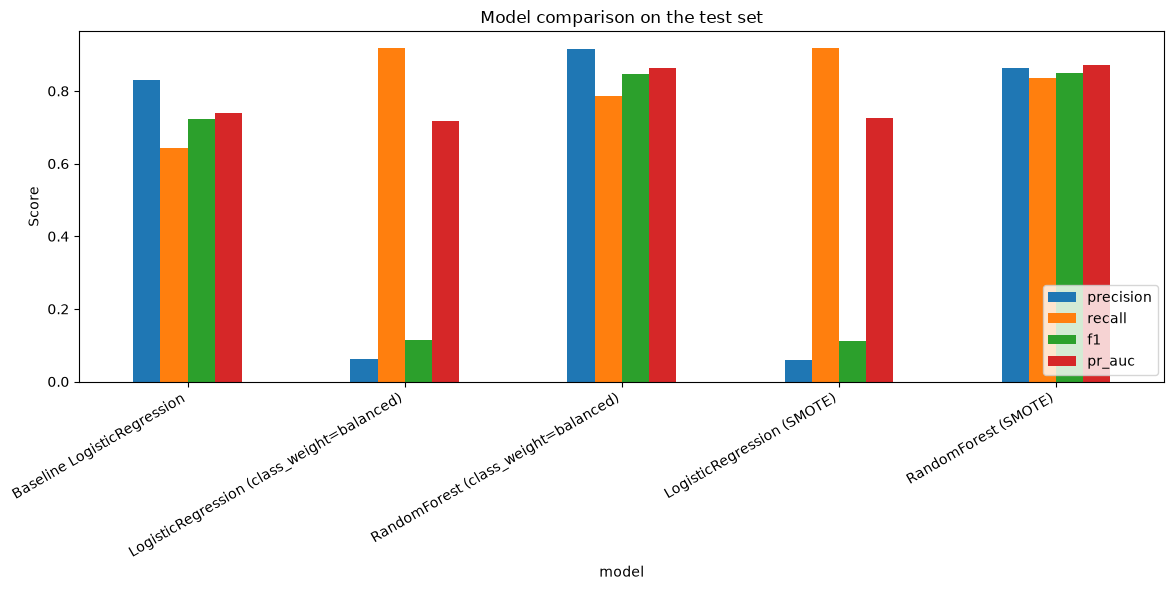

In [22]:
results_df[["precision", "recall", "f1", "pr_auc"]].plot(kind="bar", figsize=(12, 6))
plt.title("Model comparison on the test set")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Feature importance

Using the RandomForest trained on the class-weighted data (no synthetic rows, so the importances reflect the original data directly).

In [23]:
importances = pd.Series(rf_balanced.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(15)

V14       0.191389
V10       0.106915
V4        0.105672
V12       0.097590
V17       0.090374
V3        0.065613
V11       0.046519
V16       0.044653
V2        0.038312
V9        0.025415
V7        0.017631
V21       0.017407
V20       0.012643
V19       0.012447
Amount    0.011962
dtype: float64

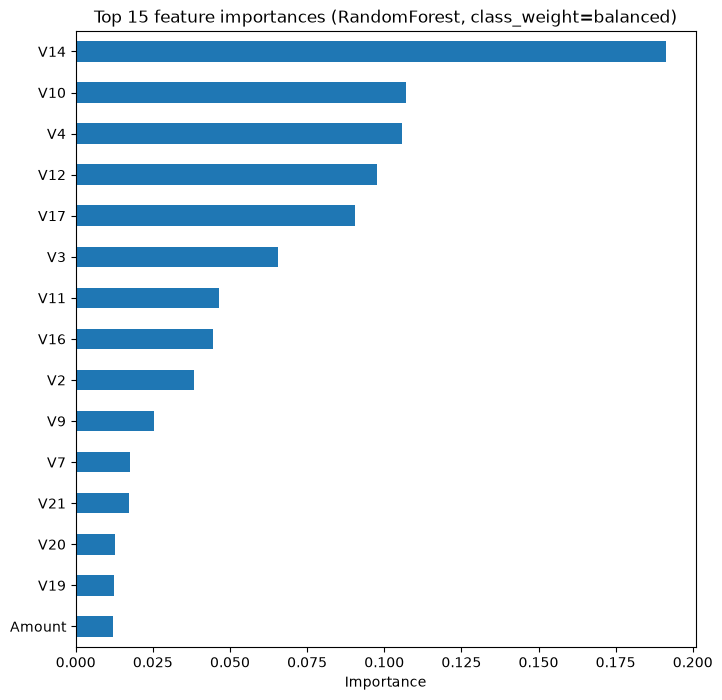

In [24]:
plt.figure(figsize=(8, 8))
importances.head(15).plot(kind="barh")
plt.title("Top 15 feature importances (RandomForest, class_weight=balanced)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

## Cross-validation

A single train/test split can be misleading with so few fraud cases in the test set. Stratified k-fold cross-validation, scored on PR-AUC (more informative than accuracy on imbalanced data), gives a more robust estimate for the best-performing model found above.

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Replace `rf_balanced` below with whichever model scores best in the comparison above
cv_scores = cross_val_score(rf_balanced, X, y, cv=cv, scoring="average_precision", n_jobs=-1)
print(f"Cross-validated PR-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
cv_scores

Cross-validated PR-AUC: 0.8510 (+/- 0.0276)


array([0.82512668, 0.89612304, 0.86098626, 0.85344914, 0.81951458])

### Insight: What the model comparison shows

- **RandomForest handles this imbalance much better than LogisticRegression.** With `class_weight="balanced"` or SMOTE, LogisticRegression reaches high recall (91.8%) but its precision collapses to about 6% - it correctly flags most fraud, but floods the results with false positives. RandomForest keeps a much better balance: 78.6% recall at 91.7% precision with class weights, and 83.7% recall at 86.3% precision with SMOTE.
- **RandomForest + SMOTE is the best model overall on this test set** (PR-AUC 0.870, F1 0.850), slightly ahead of RandomForest + class_weight (PR-AUC 0.863, F1 0.846). The baseline LogisticRegression, with no imbalance handling at all, is a distant third (PR-AUC 0.739, F1 0.724) - it still works reasonably, since 0.17% fraud is imbalanced but not extreme, but it misses more fraud than either RandomForest variant (64.3% recall vs 78-84%).
- **5-fold cross-validation on the class-weighted RandomForest gives PR-AUC 0.851 (+/- 0.028)**, close to the single test-split score (0.863), which suggests the result is reasonably stable and not just a lucky split.
- **`V14`, `V10`, `V4`, `V12`, and `V17` are the most important features** for the RandomForest model, together making up more than half of the total feature importance. `Amount` barely matters (1.2% importance) - the anonymized PCA components carry almost all the signal for this model, which is expected since PCA was applied specifically to concentrate the fraud-relevant variance into a handful of components.
- **Takeaway for model choice**: if the goal is to flag as much fraud as possible regardless of false positives, a class-weighted or SMOTE-trained LogisticRegression is not usable in practice here (94% of its fraud flags are false alarms). RandomForest with SMOTE is the more balanced, production-realistic choice on this dataset.